## 1. Hidden Markov Model

Markets exhibit periods with disticnt behaviour and characteristics, these patterns are commonly refered to as market regimes. Market regimes are not directly defined or observable, however identifying these persistent changes in market behaviour can be useful for investment and risk-management decisions. For example, characteristics of a "crisis" market regime could be characterized by extreme volatility, large  absolute returns and persistant negative trends. Identifying such regimes could provide additional information about the current level of market risk.

Market regimes can be described as latent states that can't be observed directly. A Hidden Markov Model (HMM) provides a probabilistic framework that can be used to find hidden states through observable market data. The implied regimes depend strongly on the information provided to the model. The initial specification in this notebook uses three features: daily log returns, momentum, and conditional volatility estimated by the GARCH(1,1) model. 

The objective of this notebook is to evaluate whether the implemented HMM can identify persistent and economically interpretable market regimes, and then investigate how the model specification affects the resulting regime classification.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, norm
import statsmodels.api as smapi
import statsmodels as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns

project_root = Path.cwd().parent


if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    

In [2]:
from src import data_loader as dl
from src import preprocessing as pp
from src import garch
from src import features
from src.markov_model.hmm import HiddenMarkovModel as hmm
from src.markov_model.forward import forward_filtering
from src.markov_model.backward import backward_filtering
from sklearn.preprocessing import StandardScaler

# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)
vix = dl.load_market_data(ticker = "^VIX")
garch_output = garch.fit_garch(market_data["Return"]*100)

## 2. Data & baseline features 

The initial dataset is the S&P 500 market/price data spaning from 2000-01-01 through present date. This dataset is utilized to construct the baseline features, which include daily log returns, a 20-day momentum window, and conditional volatility extracted from a GARCH(1,1) model. To prevent overfitting and the introduction of unnecessary noise, it is preferable to train the Hidden Markov Model (HMM) on a limited set of distinct features initially. Starting with a parsimonious feature set limits model complexity and provides an interpretable baseline from which additional features can later be evaluated.

These baseline features capture distinct market dynamics: daily log returns capture the direction and magnitude of short-term price changes, momentum captures trend behavior, and conditional volatility serves as a proxy for current market risk. Finally, the dataset is partitioned chronologically, reserving the first 70% of the observations for in-sample training and the remaining 30% for out-of-sample evaluation.

### 2.1 Descriptive Statistics of Training Set

In [3]:
baseline_features = features.build_baseline_features(market_data,garch_output)

split_idx = int(len(baseline_features) * 0.70)

train_df = baseline_features.iloc[:split_idx].copy()
test_df = baseline_features.iloc[split_idx:].copy()

sp_price_train = market_data.loc[train_df.index,"Close"]
sp_price_test = market_data.loc[test_df.index,"Close"]



baseline_X_train = train_df.copy()
baseline_X_test = test_df.copy()
dates = train_df.index

baseline_X_train.describe()
#X_train.corr()

,Returns,Momentum_20,Conditional_Volatility
count,4680.000000,4680.000000,4680.000000
mean,0.000152,0.002995,0.010677
std,0.012023,0.045694,0.006152
min,-0.094695,-0.330730,0.003931
25%,-0.004810,-0.017496,0.006749
50%,0.000538,0.009965,0.008980
75%,0.005643,0.029223,0.012619
max,0.109572,0.211030,0.058699


#### Discussion 

The baseline features exhibit noticeably different statistical properties and scales. Momentum has the largest variance, with a standard deviation of approximately 0.046, compared with 0.012 for daily log returns and 0.006 for conditional volatility. Both returns and momentum take positive and negative values and are centered relatively close to zero, whereas conditional volatility is strictly positive and centered around 0.011. Conditional volatility also exhibits a smaller variation relative to its mean. These differences suggest that the features capture different aspects of market behaviour, however the differences in scale should be considered when specifying the HMM.

### 2.2 Correlation Matrix of Training Set

In [4]:
baseline_X_train.corr()

,Returns,Momentum_20,Conditional_Volatility
Returns,1.000000,0.215972,0.001065
Momentum_20,0.215972,1.000000,-0.444535
Conditional_Volatility,0.001065,-0.444535,1.000000


#### Discussion

The correlation matrix exhbits no linnear correlation (0.001) between daily returns and conditional volatility, not out of character since volatility describes uncertainty in the market rather than direction. Momentum and returns have a weak positive correlation (0.216), which is reasonable since the daily return is part of the current momentum window. The strongest relationship is observed between momentum and conditional volatility, with a correlation of -0.445. This indicates that periods of elevated conditional volatility tend to exhibit weaker momentum, demonstrating the combination of negative trends and elevated volatility often observed during periods of market stress.

### 2.3 Feature Scaling

The baseline features have different numerical scales, which can affect the KMeans initialization of the HMM. The features are standardized to have zero mean and unit variance. To prevent data leakage, the scaler is fitted exclusively on the training data and then applied to the test data using the same transformation.

In [6]:
scaler = StandardScaler()
baseline_X_train = scaler.fit_transform(baseline_X_train)
baseline_X_test = scaler.transform(baseline_X_test)

print("Means:", baseline_X_train.mean(axis=0))
print("Standard deviations:", baseline_X_train.std(axis=0))

Means: [3.03650742e-18 0.00000000e+00 4.85841187e-17]
Standard deviations: [1. 1. 1.]


## 3. Baseline HMM

The baseline Hidden Markov Model is specified with three hidden states, creating a model that can distinguish between different market conditions while keeping it initialy relatively simple. A full covariance structure is used, this to allow the model to capture dependencies between the standardized log returns, 20-day momentum, and conditional volatility features.

The model is trained on the first 70% of the observations using a chronological split, while the remaining 30% is reserved for out-of-sample evaluation. Model parameters are initialized using KMeans clustering before being iteratively estimated using the Baum–Welch algorithm. Training continues until the change in log-likelihood falls below the convergence tolerance of $10^{−5}$, or until the maximum of 100 iterations is reached.

This specification serves as the baseline model. The number of states, covariance structure, and feature specification will be evaluated and compared in later sections rather than assumed to be optimal.

In [7]:
HMM = hmm(feature_matrix = baseline_X_train, states = 3, covariance_type = "full").fit()

### 3.1 Convergence

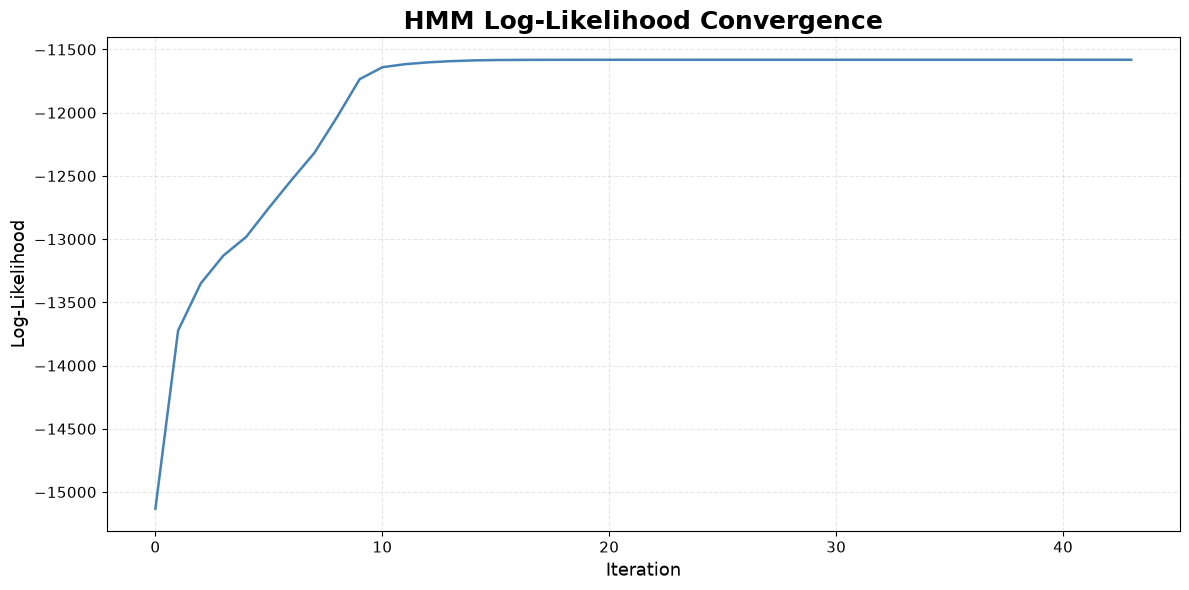

Iterations: 44
Initial LL: -15131.692403664918
Final LL: -11581.497313215417
Final improvement: 8.182329111150466e-06
Number of decreases: 0


In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    HMM.log_likelihood_history,
    linewidth=1.8,
    color="steelblue"
)

plt.title(
    "HMM Log-Likelihood Convergence",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Iteration", fontsize=13)
plt.ylabel("Log-Likelihood", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()

ll = np.array(HMM.log_likelihood_history)

print("Iterations:", len(ll))
print("Initial LL:", ll[0])
print("Final LL:", ll[-1])
print("Final improvement:", ll[-1] - ll[-2])
print("Number of decreases:", np.sum(np.diff(ll) < 0))

#### Discussion

The HMM shows significant improvement in log-likelihood during training, increasing from approximately -15,132 to -11,581. The largest improvements happens during the first iterations, after which the rate of improvement decreases and the log-likelihood begins to level off after approximately 10 iterations. The final improvement is only $8.18×10^{−6}$, this indicates that further parameter updates have a extremly small effect on the objective function.

No decreases in log-likelihood are observed during the training process, which is consistent with the expected behaviour of the Baum–Welch algorithm. Training terminates after 44 iterations when the improvement in log-likelihood falls below the convergence tolerance of $10^{−5}$. These results concludes stable numerical convergence of the baseline HMM however they do not prove that the selected model specification or identified regimes are economically meaningful.

### 3.2 State Means

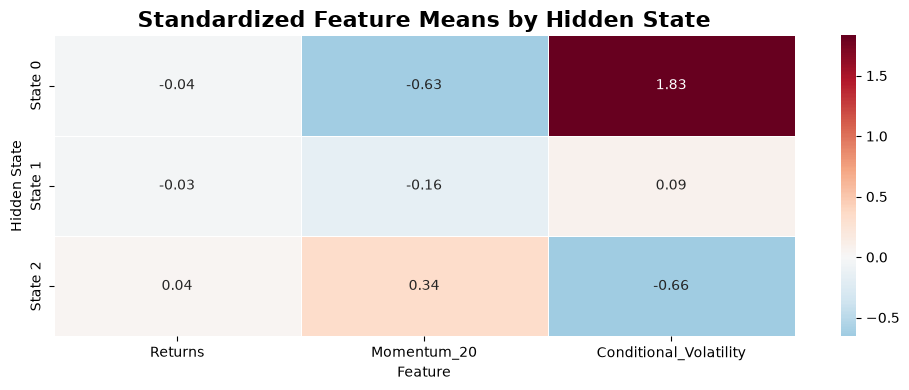

In [10]:


state_means_scaled = pd.DataFrame(
    HMM.means,
    columns=baseline_features.columns,
    index=[f"State {i}" for i in range(HMM.states)]
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    state_means_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Standardized Feature Means by Hidden State",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Feature")
plt.ylabel("Hidden State")

plt.tight_layout()
plt.show()

#### Discussion

State 2 exhibits returns close to the training mean, moderately positive momentum, and substantially lower conditional volatility. This suggests that State 2 is associated with periods of relatively low volatility and positive medium-term price trends. State 1 also exhibits daily returns close to the mean, but is characterized by negative momentum and substantially elevated conditional volatility. Interestingly, the relatively small difference in mean daily returns between States 2 and 0 suggests that daily returns alone provide limited separation between the regimes, whereas their behaviour over the 20-day momentum window differs more clearly.

State 1 is less distinctive, with all three feature means relatively close to the training average, potentially representing more intermediate market conditions. Overall conditional volatility exhibits the greatest separation across state means, then momentum and daily returns differ only slightly. Based on these characteristics, State 0 may represent a low-volatility positive-trend regime, State 0 a high-volatility negative-trend regime, and State 1 an intermediate regime. These interpretations remain preliminary until the states are examined over time.

### 3.3 Original-scale State Means

In [11]:
state_means_original = pd.DataFrame(
    scaler.inverse_transform(HMM.means),
    columns=baseline_features.columns,
    index=[f"State {i}" for i in range(HMM.states)]
)

state_means_original.style.set_caption("Original-scale State Means")

,Returns,Momentum_20,Conditional_Volatility
State 0,-0.000352,-0.025698,0.021954
State 1,-0.000172,-0.004364,0.011242
State 2,0.000602,0.018605,0.006637


#### Discussion

Transforming the state means back to their original scale improves their economic interpretability. The original-scale feature means are consistent with the observations in the standardized heatmap. State 1 exhibits small positive daily returns, positive 20-day momentum, and relatively low conditional volatility. State 0 exhibits small negative daily returns, more distinct negative 20-day momentum, and substantially higher conditional volatility. State 1 exhibits daily returns close to zero and relatively weak momentum, while conditional volatility is higher than in State 2 but substantially lower than in State 0.

Overall, the original-scale representation provides a more intuitive economic interpretation of the differences between the identified regimes, while supporting the same general patterns observed in the standardized state means.

### 3.4 Transition Matrix

In [12]:
transition_matrix = pd.DataFrame(
    HMM.transition_matrix,
    index=[f"From State {i}" for i in range(HMM.states)],
    columns=[f"To State {i}" for i in range(HMM.states)]
)

transition_matrix.style.set_caption("Transition Matrix")
transition_matrix.round(4)

,To State 0,To State 1,To State 2
From State 0,0.9731,0.0269,0.0000
From State 1,0.0092,0.9694,0.0214
From State 2,0.0001,0.0187,0.9812


#### Discussion 

The transition matrix indicates that all three states are highly persist, with relativly low probabilities of switching regime. Both State 0 and State 2 have substanially higher probabilities of switching to State 1 than directly to each other. The probabilities of direct transitions bewteen State 2 and State 0 is extremely low. This supports the initial hypothesis that State 1 acts as an intermediate regime between the low-volatility, positive-trend conditions of State 2 and the high-volatility, negative-trend conditions of State 0.  When leaving State 1, the model is more likely to transition to State 2 than to State 0. 

### 3.5 Expected State Duration

In [13]:
expected_durations = 1 / (1 - np.diag(HMM.transition_matrix))

duration_df = pd.DataFrame(
    {
        "Expected Duration (Trading Days)": expected_durations
    },
    index=[f"State {i}" for i in range(HMM.states)]
)

duration_df.round(2)

,Expected Duration (Trading Days)
State 0,37.23
State 1,32.70
State 2,53.17


#### Discussion

The expected state durations further support the high regime persistence observed in the transition matrix. State 2 has the longest expected duration at approximately 53 trading days, followed by State 0 at 37 days and State 1 at 33 days. State 2 therefore appears substantially more persistent, while States 0 and 1 have relatively similar expected durations. The shorter duration of State 1, combined with the transition patterns observed previously, provides further support for its preliminary interpretation as an intermediate regime between States 0 and 2.

### 3.6 State Occupancy

In [14]:
smooth_probs = HMM.smooth_proba(baseline_X_train)

state_occupancy = smooth_probs.mean(axis=0)

occupancy_df = pd.DataFrame(
    {"Occupancy": state_occupancy},
    index=[f"State {i}" for i in range(HMM.states)]
)

occupancy_df["Occupancy (%)"] = occupancy_df["Occupancy"] * 100

occupancy_df.round(2)

,Occupancy,Occupancy (%)
State 0,0.14,14.14
State 1,0.41,40.68
State 2,0.45,45.18


#### Discussion

The smoothed state probabilities indicate that State 2 has the highest occupancy with 45.15%,  followed by State 1 with 40.70%. State 0 has a lower occupancy of 14,15%. From an economical perspective, the lower frequency of State 0 is consistent with its previously identified characteristics of elevated volatility and negative momentum, which may represent less common periods of market stress.

The relatively high occupancy of State 1 challenges the initial interpretation of it as simply an intermediate regime between States 0 and 2. Although the transition matrix suggests that State 1 facilitates transitions between the two more distinct regimes, its high occupancy indicates that it may also represent a persistent and economically relevant market environment itself.

## 4. Regime Analysis Over Time

The previous analysis characterized the hidden states through their feature means, transition probabilities, expected durations, and state occupancy. These statistics do not reveal when the identified regimes occur or how they evolve through time. This section will examine the estimated state probabilities and regime classifications across the historical market data. The objective is to evaluate whether the identified states correspond to economically meaningful market periods and to examine how confidently the model distinguishes between regimes.

### 4.1 Smoothed State Probabilities

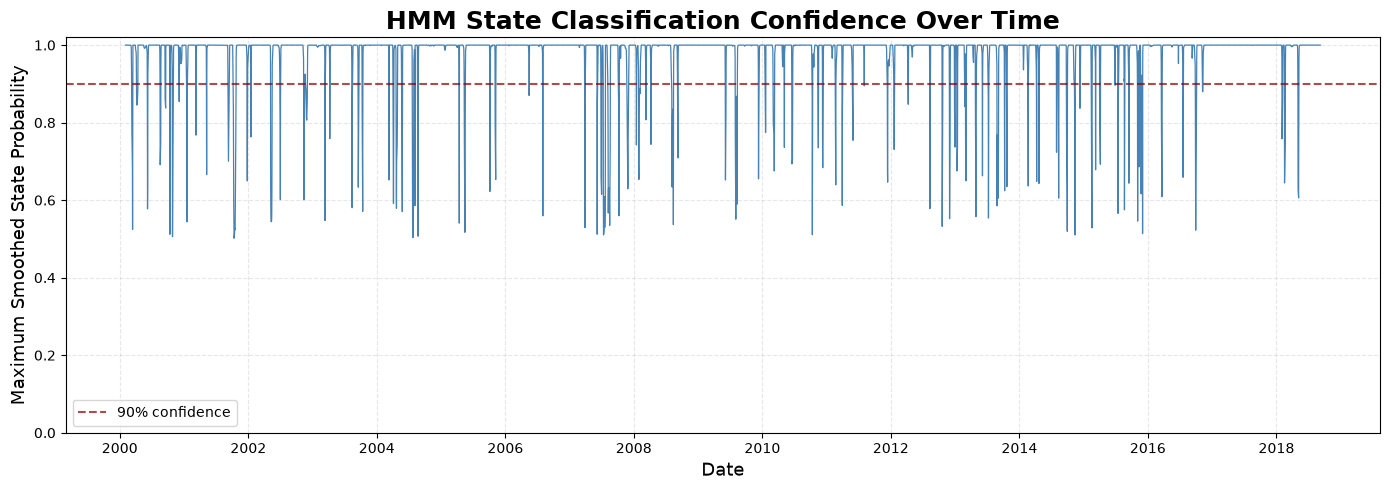

In [23]:
plt.figure(figsize=(14, 5))
max_probs = smooth_probs.max(axis=1)

plt.plot(
    train_df.index,
    max_probs,
    color="steelblue",
    linewidth=0.9
)

plt.axhline(
    0.90,
    color="darkred",
    linestyle="--",
    alpha=0.7,
    label="90% confidence"
)

plt.title(
    "HMM State Classification Confidence Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=13)
plt.ylabel("Maximum Smoothed State Probability", fontsize=13)

plt.ylim(0, 1.02)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### Discussion

The model is generally confident in its regime classifications with a mean of 98 percent condfidence. The maximum probability exceeds 99% for approximately 87% of the observations, indicating that the model typically distinguishes clearly between the identified regimes. However, the mean confidence on regime-switching days decreases considerably to approximately 73%. This suggests more uncertainty around regime transitions, where observations may share characteristics with multiple states. 

### 4.2 Historical Regime Classification

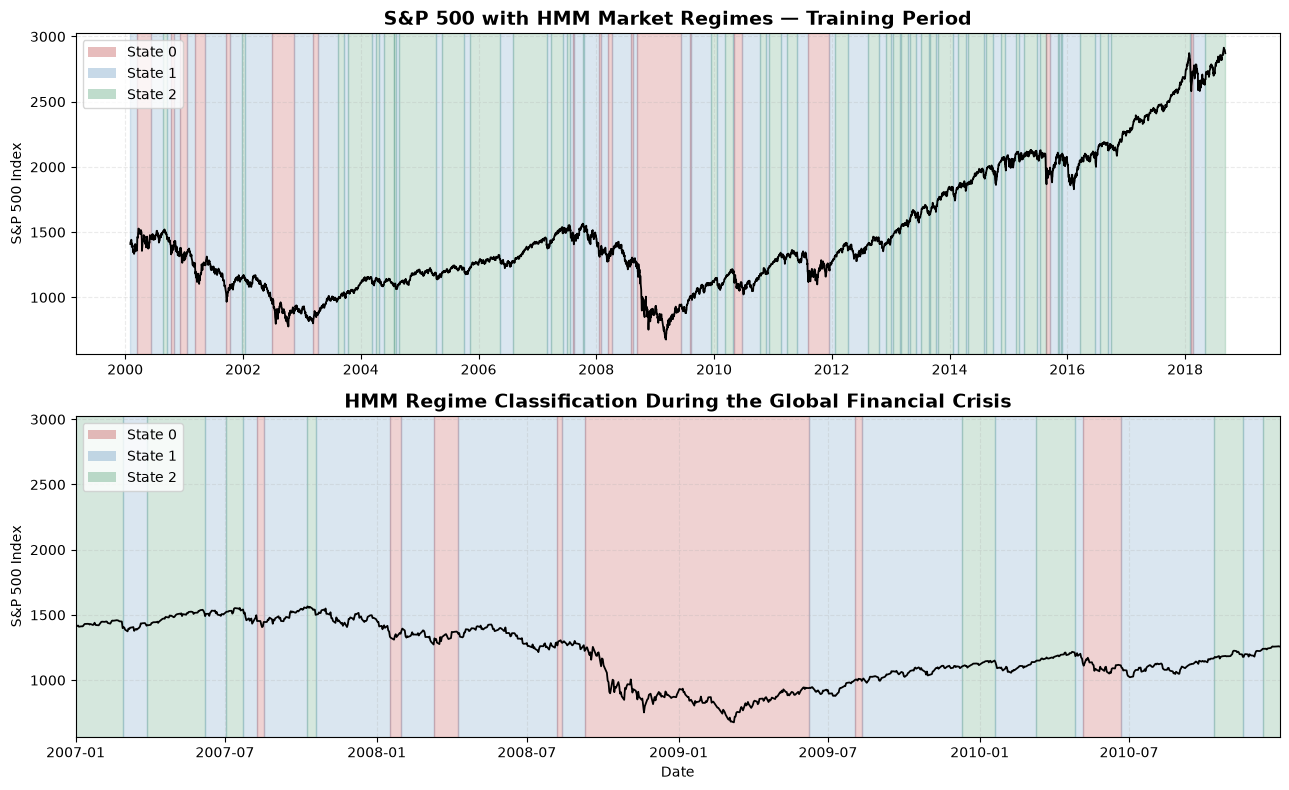

In [25]:
from matplotlib.patches import Patch

smoothed_states = np.argmax(HMM.smooth_proba(baseline_X_train),axis=1)

state_colors = {0:"firebrick",1: "steelblue",2: "seagreen"}
fig, axes = plt.subplots(2, 1, figsize=(13, 8))


def add_regime_background(ax, dates, states):
    current_state = states[0]
    start = 0

    for i in range(1, len(states)):
        if states[i] != current_state:
            ax.axvspan(
                dates[start],
                dates[i],
                color=state_colors[current_state],
                alpha=0.20
            )

            current_state = states[i]
            start = i

    ax.axvspan(
        dates[start],
        dates[-1],
        color=state_colors[current_state],
        alpha=0.20
    )


# --------------------------------------------------
# Plot 1 — Full training period
# --------------------------------------------------

axes[0].plot(dates, sp_price_train, color="black", linewidth=1.3)
add_regime_background(axes[0], dates, smoothed_states)

axes[0].set_title("S&P 500 with HMM Market Regimes — Training Period",fontsize=14,fontweight="bold")
axes[0].set_ylabel("S&P 500 Index")
axes[0].grid(True, linestyle="--", alpha=0.25)

# --------------------------------------------------
# Plot 2 — Financial Crisis
# --------------------------------------------------

axes[1].plot(dates, sp_price_train, color="black", linewidth=1.3)
add_regime_background(axes[1], dates, smoothed_states)
axes[1].set_xlim(pd.Timestamp("2007-01-01"), pd.Timestamp("2010-12-31"))
axes[1].set_title("HMM Regime Classification During the Global Financial Crisis", fontsize=14, fontweight="bold")

axes[1].set_xlabel("Date")
axes[1].set_ylabel("S&P 500 Index")
axes[1].grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()

legend_elements = [
    Patch(facecolor="firebrick", alpha=0.3, label="State 0"),
    Patch(facecolor="steelblue", alpha=0.3, label="State 1"),
    Patch(facecolor="seagreen", alpha=0.3, label="State 2")
]

axes[0].legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)

axes[1].legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)

plt.show()

#### Discussion

The historical classification supports the previous interpretation of the hidden states. State 2 primarily occurs during periods of stable market growth, while State 0 is associated with declining markets and elevated stress. State 1 appears more frequently during moderate or transitional market conditions.

The 2008 Financial Crisis provides a clear example. During 2007 and early 2008, the model primarily switches between States 2 and 1. Later into 2008 and beginning of 2009, after the colapse of Bear Sterns and Lehman Brothers, State 0 becomes dominant. The model does not identify the crisis regime at its earliest stage, however this is reasonable since the HMM identifies changes in observed market characteristics rather than predicting future regimes. While the historical classification is economically credible an out-of-sample evaluation is required to decide whether these patterns generalize.

### 4.3 Smoothed vs Viterbi Classification

The smoothed classification selects the most probable state for each individual day, while Viterbi identifies the most probable state sequence over the entire period. Comparing the two shows whether the choice of classification method significantly affects the identified market regimes.

In [26]:
smoothed_states = np.argmax(HMM.smooth_proba(baseline_X_train), axis=1)

viterbi_states = HMM.decode_viterbi(baseline_X_train)
agreement = np.mean(smoothed_states == viterbi_states)

print(f"Agreement: {agreement:.2%}")

Agreement: 99.19%


#### Discussion

The two methods agree on 99.06% of the state classifications, showing that they produce almost identical regime sequences. This is consistent with the previously observed high classification confidence. However, this does not show how well the model performs on unseen data, which will be evaluated out-of-sample.

## 5. Out-of-Sample Evaluation

The model has so far been evaluated using the same data on which it was trained on. To examine whether the identified regimes generalize to unseen market data, the fitted HMM is now evaluated on the remaining 30% of the dataset. The model parameters will remain during the evaluation, allowing the out-of-sample regime classifications to be compared with the characteristics identified during training.

### 5.1 Out-of-Sample Regime Classification

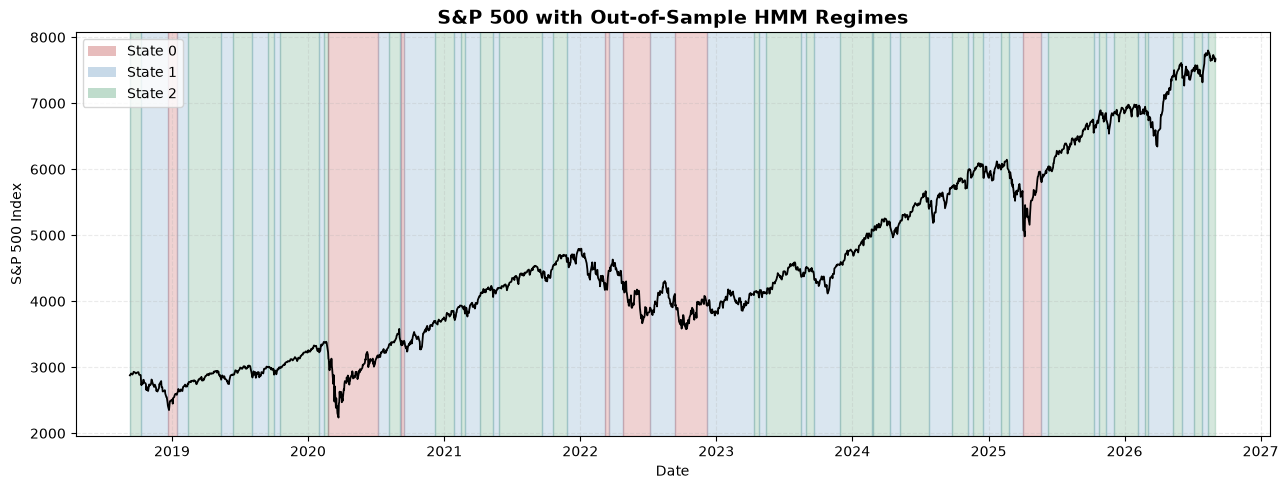

In [27]:
test_smoothed_probs = HMM.smooth_proba(baseline_X_test)
test_smoothed_states = np.argmax(test_smoothed_probs, axis=1)
fig, ax = plt.subplots(figsize=(13, 5))

# S&P 500 price
ax.plot(
    test_df.index,
    sp_price_test,
    color="black",
    linewidth=1.3
)

#HMM Regimes
add_regime_background(ax, test_df.index, test_smoothed_states)

ax.set_title("S&P 500 with Out-of-Sample HMM Regimes", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("S&P 500 Index")
ax.grid(True, linestyle="--", alpha=0.25)

legend_elements = [
    Patch(facecolor="firebrick", alpha=0.3, label="State 0"),
    Patch(facecolor="steelblue", alpha=0.3, label="State 1"),
    Patch(facecolor="seagreen", alpha=0.3, label="State 2")
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

#### Discussion

The out-of-sample classification further strengthens the initial interpretation of the hidden states. State 2 generally occurs during periods of stable market growth, while State 0 is associated with declining markets and elevated stress. State 1 appears more frequently during moderate or transitional market conditions.

The model notably classifies the 2020 COVID-19 market crash as State 0, followed by transitions between States 2 and 1 during the following recovery. State 0 also reappears during periods of market stress in 2022 and in 2025. Overall, the results suggest that the economic interpretation of the regimes remains meaningful on previously unseen data. 

### 5.2 In-Sample vs Out-of-Sample Behaviour

In [28]:
train_states = np.argmax(HMM.smooth_proba(baseline_X_train), axis=1)
test_states = np.argmax(HMM.smooth_proba(baseline_X_test), axis=1)

train_regimes = train_df.copy()
test_regimes = test_df.copy()

train_regimes["State"] = train_states
test_regimes["State"] = test_states

train_means = train_regimes.groupby("State").mean()
test_means = test_regimes.groupby("State").mean()

comparison = pd.concat(
    [train_means, test_means],
    keys=["In-Sample", "Out-of-Sample"],
    axis=1
)

display(comparison.round(4))

In-Sample                                    Out-of-Sample              \
        Returns Momentum_20 Conditional_Volatility       Returns Momentum_20   
State                                                                          
0       -0.0004     -0.0259                 0.0220       -0.0004     -0.0236   
1       -0.0002     -0.0045                 0.0113        0.0004      0.0011   
2        0.0006      0.0187                 0.0066        0.0009      0.0282   

                              
      Conditional_Volatility  
State                         
0                     0.0224  
1                     0.0111  
2                     0.0070

#### Discussion

The out-of-sample results show that the main economic characteristics of the regimes remain stable. State 2 continues to exhibit positive returns, positive momentum, and low volatility, while State 0 maintains negative returns, negative momentum, and substantially higher volatility. State 1 remains the intermediate-volatility regime, although its returns and momentum shift from slightly negative in-sample to slightly positive out-of-sample.

Overall, the similarity between the in-sample and out-of-sample characteristics suggests that the HMM identifies economically consistent regimes beyond the data used for training.

## 6. Model Robustness & Selection

The baseline HMM has showed economically interpretable regimes that remain consistent out-of-sample. However, the resulting regime structure may depend on modelling choices such as the number of hidden states and the selected input features. This section evaluates alternative model specifications to determine whether the baseline results are robust and whether alternative configurations provide a better representation of market regimes.

### 6.1 Number of Hidden States

In [215]:
state_range = range(2, 11)

models = {}

for n_states in state_range:
    model = hmm(feature_matrix=baseline_X_train, states=n_states, covariance_type="full")
    model.fit(max_itr=100, tol=1e-5)
    models[n_states] = model


In [ ]:

results = []
n = len(baseline_X_train)

for K, model in models.items():
    D = X_train.shape[1]
    k = (
        (K - 1)                    # Initial probabilities
        + K * (K - 1)              # Transition matrix
        + K * D                    # Means
        + K * (D * (D + 1) / 2)    # Full covariance matrices
    )
    
    log_likelihood = model.log_likelihood_history[-1]

    # Calculate AIC
    aic = 2*k - 2*log_likelihood

    # Calculate BIC
    bic = k*np.log(n) - 2*log_likelihood

    results.append({
        "States": K,
        "Log-Likelihood": log_likelihood,
        "Parameters": k,
        "AIC": aic,
        "BIC": bic
    })

results_df = pd.DataFrame(results)

display(results_df.round(2))


#### Discussion

Both AIC and BIC decrease as the number of hidden states increases, suggesting that the improved model fit outweighs the penalty for additional complexity. However, more states do not necessarily result in a better model, as the regimes may become difficult to interpret economically. Therefore, AIC and BIC should be considered together with regime stability, occupancy and economic interpretation.

### 6.2 Three-State vs Six-State Model

In [217]:
model_6 = models[6]

# Smoothed classification on training data
probs_6 = model_6.smooth_proba(baseline_X_train)
states_6 = np.argmax(probs_6, axis=1)

occupancy_6 = np.bincount(states_6, minlength=model_6.states) / len(states_6)

regimes_6 = train_df.copy()
regimes_6["State"] = states_6

means_6 = regimes_6.groupby("State").mean()

comparison_6 = means_6.copy()
comparison_6.insert(0, "Occupancy (%)", occupancy_6 * 100)

comparison_6.index = [f"State {i}" for i in range(model_6.states)]

display(comparison_6.round(4))

,Occupancy (%),Returns,Momentum_20,Conditional_Volatility
State 0,13.0026,0.0013,0.0381,0.0111
State 1,13.7511,-0.0017,-0.0392,0.0133
State 2,21.8563,-0.0002,-0.0085,0.0089
State 3,4.1916,-0.0001,-0.0571,0.0316
State 4,37.7459,0.0007,0.0223,0.0064
State 5,9.4525,0.0002,-0.0079,0.0182


#### Discussion

The six-state model provides a more specific representation of market conditions, separating calm, bullish, bearish and extreme-stress periods into regimes. However, several states represent relatively similar market conditions at different volatility or momentum levels, making the regime structure less straightforward to interpret than the three-state specification.

### 6.3 Regime Stability

In [220]:
train_probs_6 = model_6.smooth_proba(baseline_X_train)
test_probs_6 = model_6.smooth_proba(baseline_X_test)

train_states_6 = np.argmax(train_probs_6, axis=1)
test_states_6 = np.argmax(test_probs_6, axis=1)

# Add state labels to original-scale feature data
train_regimes_6 = train_df.copy()
test_regimes_6 = test_df.copy()

train_regimes_6["State"] = train_states_6
test_regimes_6["State"] = test_states_6

# Mean feature values within each state
train_means_6 = train_regimes_6.groupby("State").mean()
test_means_6 = test_regimes_6.groupby("State").mean()

# Combine train vs test
stability_6 = pd.concat(
    [train_means_6, test_means_6],
    keys=["In-Sample", "Out-of-Sample"],
    axis=1
)

train_occupancy_6 = np.bincount(train_states_6, minlength=model_6.states) / len(train_states_6)
test_occupancy_6 = np.bincount(test_states_6, minlength=model_6.states) / len(test_states_6)
occupancy_comparison = pd.DataFrame({
    "In-Sample (%)": train_occupancy_6 * 100,
    "Out-of-Sample (%)": test_occupancy_6 * 100
})

occupancy_comparison.index = [
    f"State {i}" for i in range(model_6.states)
]



display(stability_6.round(4))

display(occupancy_comparison.round(2))

In-Sample                                    Out-of-Sample              \
        Returns Momentum_20 Conditional_Volatility       Returns Momentum_20   
State                                                                          
0        0.0013      0.0381                 0.0111        0.0022      0.0462   
1       -0.0017     -0.0392                 0.0133       -0.0013     -0.0364   
2       -0.0002     -0.0085                 0.0089       -0.0005     -0.0054   
3       -0.0001     -0.0571                 0.0316        0.0005     -0.0534   
4        0.0007      0.0223                 0.0064        0.0010      0.0313   
5        0.0002     -0.0079                 0.0182        0.0004     -0.0133   

                              
      Conditional_Volatility  
State                         
0                     0.0110  
1                     0.0133  
2                     0.0090  
3                     0.0370  
4                     0.0067  
5                     0.0177

,In-Sample (%),Out-of-Sample (%)
State 0,13.00,15.71
State 1,13.75,13.17
State 2,21.86,22.00
State 3,4.19,3.29
State 4,37.75,36.86
State 5,9.45,8.98


#### Discussion

The three-state specification is retained as the baseline model because it provides a simpler and more economically interpretable representation of market regimes. Although the six-state model achieves a better statistical fit and remains stable out-of-sample, the additional states mainly provide a more granular separation of similar market conditions. For the purpose of regime-based risk modelling, the three-state model therefore provides a better balance between model complexity and economic interpretability.

### 6.4 Ablation Feature Analysis

The choice of input features directly affects how the HMM identifies and separates market regimes. To evaluate the importance of the selected features, an ablation analysis is performed by removing one feature at a time from the baseline model. The resulting models are compared to determine which features contribute most to the identified regime structure.

In [32]:
feature_sets = {
    "No Returns": ["Momentum_20", "Conditional_Volatility"],
    "No Momentum": ["Returns", "Conditional_Volatility"],
    "No Volatility": ["Returns", "Momentum_20"]
}

feature_models = {}

for name, columns in feature_sets.items():
    X_temp = scaler.fit_transform(train_df[columns])
    model = hmm(feature_matrix=X_temp, states=3, covariance_type="full").fit()

    probs = model.smooth_proba(X_temp)
    states = np.argmax(probs, axis=1)

    feature_models[name] = {
        "model": model,
        "states": states,
        "columns": columns
    }

In [33]:
for name, result in feature_models.items():
    columns = result["columns"]
    states = result["states"]

    temp = train_df[columns].copy()
    temp["State"] = states

    means = temp.groupby("State").mean()
    occupancy = pd.Series(states).value_counts(normalize=True).sort_index() * 100

    means.insert(0, "Occupancy (%)", occupancy.values)

    print(f"\n{name}")
    display(means.round(4))


No Returns


,Occupancy (%),Momentum_20,Conditional_Volatility
State,,,
0,39.5940,-0.0050,0.0112
1,45.2350,0.0179,0.0066
2,15.1709,-0.0208,0.0215



No Momentum


,Occupancy (%),Returns,Conditional_Volatility
State,,,
0,45.6624,0.0006,0.0066
1,15.7692,-0.0002,0.0213
2,38.5684,-0.0002,0.0111



No Volatility


,Occupancy (%),Returns,Momentum_20
State,,,
0,28.5470,-0.0007,-0.0234
1,56.5812,0.0008,0.0243
2,14.8718,-0.0007,-0.0275


#### Discussion

The ablation analysis shows that removing daily returns has a small effect on the identified regime structure. This suggests that most of the regime information is already captured by momentum and conditional volatility. Removing momentum still has the separation between low- and high-volatility states, but reduces the economic distinction between positive and negative market conditions. Removing conditional volatility changes the regime structure more substantially and removes the clear separation by volatility level. Overall the momentum and conditional volatility appear to be the main drivers of the identified regimes for the three state model.

### 6.5 Alternative Feature Specifications

The previous analysis suggests that momentum and conditional volatility contain most of the information used for regime identification. Alternative feature specifications are therefore tested to determine whether additional variables, particularly drawdown and longer-term momentum, can improve the economic separation of the identified regimes.

In [5]:
alt_features = features.build_alternative_features(market_data, vix)
all_features = pd.concat([baseline_features, alt_features], axis=1)

In [34]:


feature_sets = {
    "Baseline": [
        "Momentum_20",
        "Conditional_Volatility"
    ],

    "With Drawdown": [
        "Momentum_20",
        "Conditional_Volatility",
        "Drawdown"
    ],

    "Long Momentum": [
        "Momentum_60",
        "Conditional_Volatility"
    ]
}

feature_models = {}

for name, columns in feature_sets.items():

    # Select only features relevant for this experiment
    temp_df = all_features[columns].dropna()

    # 70/30 split for this specification
    split_idx = int(len(temp_df) * 0.70)
    temp_train = temp_df.iloc[:split_idx].copy()

    # New scaler for this model
    temp_scaler = StandardScaler()
    X_temp = temp_scaler.fit_transform(temp_train)

    model = hmm(feature_matrix=X_temp, states=3, covariance_type="full").fit()
    
    probs = model.smooth_proba(X_temp)
    states = np.argmax(probs, axis=1)

    temp = temp_train.copy()
    temp["State"] = states

    means = temp.groupby("State").mean()
    occupancy = (pd.Series(states).value_counts(normalize=True).sort_index() * 100)
    means.insert(0,"Occupancy (%)", occupancy.reindex(means.index).values)

    feature_models[name] = {
        "model": model,
        "states": states,
        "means": means,
        "scaler": temp_scaler
    }

    print(f"\n{name}")
    display(means.round(4))


Baseline


,Occupancy (%),Momentum_20,Conditional_Volatility
State,,,
0,39.5940,-0.0050,0.0112
1,45.2350,0.0179,0.0066
2,15.1709,-0.0208,0.0215



With Drawdown


,Occupancy (%),Momentum_20,Conditional_Volatility,Drawdown
State,,,,
0,28.7188,0.0125,0.0072,-0.0130
1,39.2089,0.0108,0.0081,-0.1952
2,32.0722,-0.0151,0.0169,-0.2485



Long Momentum


,Occupancy (%),Momentum_60,Conditional_Volatility
State,,,
0,45.9372,0.0402,0.0066
1,18.6586,-0.0361,0.0198
2,35.4041,-0.0077,0.0110


#### Discussion

The results show that longer-term momentum produces similar market regimes to the baseline model. Adding drawdown changes the regimes more, but does not make them easier to interpret. Therefore, momentum and conditional volatility remain the main features, while additional risk-related features are tested next.

### 6.6 Risk-Oriented Feature Extensions

The analysis in 6.5 identifies momentum and GARCH conditional volatility as the pillar features of the baseline regime structure. To examine whether additional risk information improves regime identification, three risk-oriented features are considered: rolling volatility, downside volatility, and the VIX. Each feature is added separately to the baseline specification to evaluate whether it provides economically distinct information without unnecessarily increasing model complexity.

In [6]:
feature_sets = {
    "Baseline": [
        "Momentum_20",
        "Conditional_Volatility"
    ],

    "With Downside Vol": [
        "Momentum_20",
        "Conditional_Volatility",
        "Downside_Volatility_20"
    ],

    "With Rolling Vol": [
        "Momentum_20",
        "Conditional_Volatility",
        "Rolling_Volatility_20"
    ],

    "With VIX": [
        "Momentum_20",
        "Conditional_Volatility",
        "VIX"
    ]
}

feature_models = {}

for name, columns in feature_sets.items():

    # Only keep observations available for this specification
    temp_df = all_features[columns].dropna()

    # Chronological 70/30 split
    split_idx = int(len(temp_df) * 0.70)
    temp_train = temp_df.iloc[:split_idx].copy()
    temp_test = temp_df.iloc[split_idx:].copy()

    # Scale using training data only
    temp_scaler = StandardScaler()

    X_train_temp = temp_scaler.fit_transform(temp_train)
    X_test_temp = temp_scaler.transform(temp_test)
    model = hmm(feature_matrix=X_train_temp, states=3, covariance_type="full").fit()

    # In-sample regime probabilities / states
    probs = model.smooth_proba(X_train_temp)
    states = np.argmax(probs, axis=1)

    temp = temp_train.copy()
    temp["State"] = states
    means = temp.groupby("State").mean()
    
    occupancy = (pd.Series(states).value_counts(normalize=True).sort_index() * 100)
    means.insert(0, "Occupancy (%)", occupancy.reindex(means.index).values)

    feature_models[name] = {
        "model": model,
        "scaler": temp_scaler,
        "states": states,
        "means": means,
        "train_df": temp_train,
        "test_df": temp_test,
        "X_train": X_train_temp,
        "X_test": X_test_temp
    }

    print(f"\n{name}")
    display(means.round(4))


Baseline


,Occupancy (%),Momentum_20,Conditional_Volatility
State,,,
0,39.5940,-0.0050,0.0112
1,45.2350,0.0179,0.0066
2,15.1709,-0.0208,0.0215



With Downside Vol


,Occupancy (%),Momentum_20,Conditional_Volatility,Downside_Volatility_20
State,,,,
0,44.4755,-0.0025,0.0109,0.0063
1,41.3801,0.0185,0.0065,0.0029
2,14.1445,-0.0248,0.0218,0.0132



With Rolling Vol


,Occupancy (%),Momentum_20,Conditional_Volatility,Rolling_Volatility_20
State,,,,
0,41.5305,0.0177,0.0065,0.0056
1,16.6165,-0.0205,0.0208,0.0211
2,41.8530,-0.0022,0.0107,0.0104



With VIX


,Occupancy (%),Momentum_20,Conditional_Volatility,VIX
State,,,,
0,41.8745,0.0004,0.0108,20.6697
1,15.0473,-0.0204,0.0211,35.0849
2,43.0782,0.0137,0.0068,13.2581


#### Discussion

Adding downside volatility and rolling volatility produces a similar three-regime structure to the baseline model. Both features mainly provide additional information about market volatility, with higher values during stressed regimes and lower values during calm periods.

Adding VIX also produces clear regimes. The average VIX level is approximately 13 in the calm regime, 21 in the intermediate regime, and 35 in the stressed regime. Since VIX reflects market expectations of future volatility, it provides different information from the historical volatility measures. Therefore, VIX appears to be the most useful additional feature to consider for the final model.

### 6.7 Final Model Specification

Based on the robustness and feature analysis, the final specification uses three hidden states with Momentum_20, GARCH conditional volatility, and VIX. Momentum captures the direction of recent market movements, while conditional volatility captures time-varying realized market risk. VIX adds forward-looking information about expected market volatility. The three-state specification is retained because it provides a clear distinction between calm, intermediate, and stressed market conditions while remaining economically interpretable.

In [11]:
final_features = [
    "Momentum_20",
    "Conditional_Volatility",
    "VIX"
]

final_df = all_features[final_features].dropna().sort_index()

split_idx = int(len(final_df) * 0.70)

final_train_df = final_df.iloc[:split_idx].copy()
final_test_df = final_df.iloc[split_idx:].copy()

final_scaler = StandardScaler()

X_train_final = final_scaler.fit_transform(final_train_df)
X_test_final = final_scaler.transform(final_test_df)

## 7. Benchmark Against Established HMM

To validate the custom Hidden Markov Model implementation, its results are compared with an established implementation from the hmmlearn library. Both models are fitted using the same feature set, number of hidden states, and covariance structure. The comparison focuses on log-likelihood, estimated regime characteristics, and the resulting state classifications. Similar results would provide evidence that the custom implementation correctly captures the underlying HMM dynamics.

In [13]:
from hmmlearn.hmm import GaussianHMM
hmmlearn_model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_iter=100,
    tol=1e-5
)
hmmlearn_model.fit(X_train_final)

custom_model = hmm(feature_matrix=X_train_final, states=3, covariance_type="full").fit()

### 7.1 Log-Likelihood and Convergence

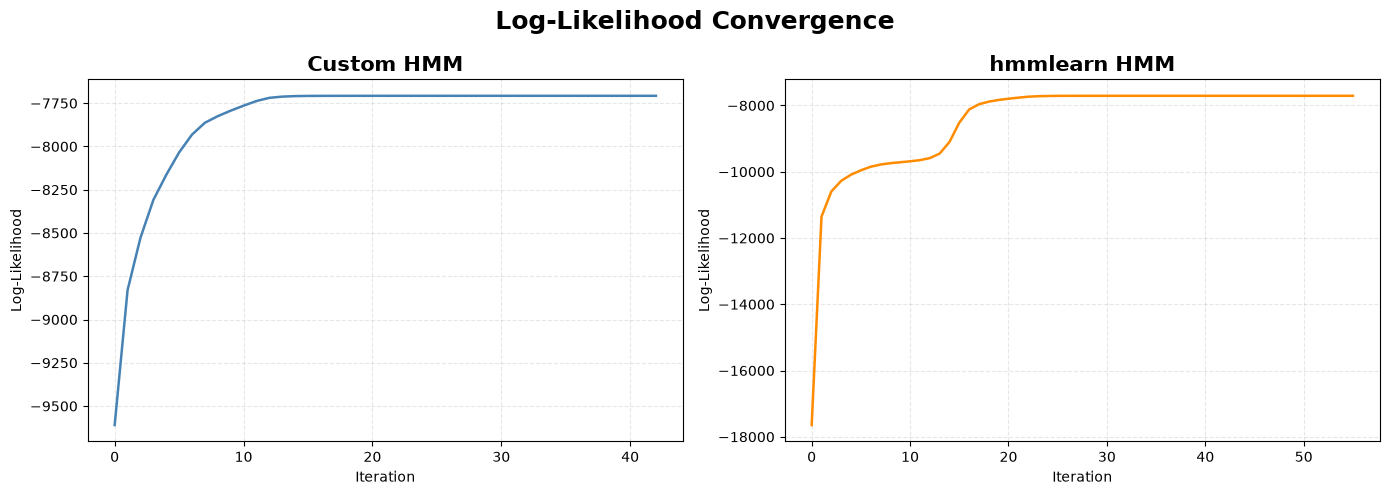

Custom HMM
Iterations: 43
Initial LL: -9609.642520998426
Final LL: -7707.26097509466
Final improvement: 9.418983609066345e-06
Number of decreases: 0

hmmlearn HMM
Iterations: 56
Initial LL: -17644.83666471772
Final LL: -7707.261015178111
Final improvement: 8.056565093284007e-06
Number of decreases: 0


In [14]:
custom_ll = np.array(custom_model.log_likelihood_history)
hmmlearn_ll = np.array(hmmlearn_model.monitor_.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Custom HMM
axes[0].plot(custom_ll, linewidth=1.8, color="steelblue")
axes[0].set_title("Custom HMM",fontsize=15, fontweight="bold")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log-Likelihood")
axes[0].grid(True, linestyle="--", alpha=0.3)


# hmmlearn HMM
axes[1].plot(hmmlearn_ll, linewidth=1.8, color="darkorange")
axes[1].set_title("hmmlearn HMM", fontsize=15, fontweight="bold")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Log-Likelihood")
axes[1].grid(True, linestyle="--", alpha=0.3)

fig.suptitle("Log-Likelihood Convergence", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

print("Custom HMM")
print("Iterations:", len(custom_ll))
print("Initial LL:", custom_ll[0])
print("Final LL:", custom_ll[-1])
print("Final improvement:", custom_ll[-1] - custom_ll[-2])
print("Number of decreases:", np.sum(np.diff(custom_ll) < 0))

print("\nhmmlearn HMM")
print("Iterations:", len(hmmlearn_ll))
print("Initial LL:", hmmlearn_ll[0])
print("Final LL:", hmmlearn_ll[-1])
print("Final improvement:", hmmlearn_ll[-1] - hmmlearn_ll[-2])
print("Number of decreases:", np.sum(np.diff(hmmlearn_ll) < 0))

#### Discussion

Both implementations show stable and monotonic convergence, with no decreases in log-likelihood. The custom HMM converges after 43 iterations, while hmmlearn requires 56 iterations. Despite different initial log-likelihood values, both models converge to approximately the same final log-likelihood of -7707.26. This provides strong evidence that the custom implementation correctly performs the Baum-Welch optimization.

### 7.2 Estimated Regime Characteristics

In [15]:
# Custom HMM state classification
custom_probs = custom_model.smooth_proba(X_train_final)
custom_states = np.argmax(custom_probs, axis=1)

custom_summary = final_train_df.copy()
custom_summary["State"] = custom_states

custom_means = custom_summary.groupby("State").mean()

custom_occupancy = (pd.Series(custom_states).value_counts(normalize=True).sort_index() * 100)
custom_means.insert(0, "Occupancy (%)", custom_occupancy.reindex(custom_means.index).values)

# hmmlearn state classification
hmmlearn_states = hmmlearn_model.predict(X_train_final)

hmmlearn_summary = final_train_df.copy()
hmmlearn_summary["State"] = hmmlearn_states

hmmlearn_means = hmmlearn_summary.groupby("State").mean()
hmmlearn_occupancy = (pd.Series(hmmlearn_states).value_counts(normalize=True).sort_index() * 100)
hmmlearn_means.insert(0, "Occupancy (%)", hmmlearn_occupancy.reindex(hmmlearn_means.index).values)
print("Custom HMM")
display(custom_means.round(4))

print("hmmlearn HMM")
display(hmmlearn_means.round(4))

Custom HMM


,Occupancy (%),Momentum_20,Conditional_Volatility,VIX
State,,,,
0,41.8745,0.0004,0.0108,20.6697
1,15.0473,-0.0204,0.0211,35.0849
2,43.0782,0.0137,0.0068,13.2581


hmmlearn HMM


,Occupancy (%),Momentum_20,Conditional_Volatility,VIX
State,,,,
0,41.9390,0.0004,0.0108,20.6776
1,15.0258,-0.0205,0.0212,35.0926
2,43.0353,0.0138,0.0068,13.2476


#### Discussion

The two implementations produce nearly identical regime characteristics. State occupancies and average feature values are very similar across all three states. Both models identify an intermediate regime with moderate volatility, a stressed regime with negative momentum and high volatility, and a calm regime with positive momentum and low volatility. This provides further evidence that the custom HMM implementation produces results consistent with the established hmmlearn implementation.

### 7.3 Regime Classification Comparison

State classification agreement: 99.59%


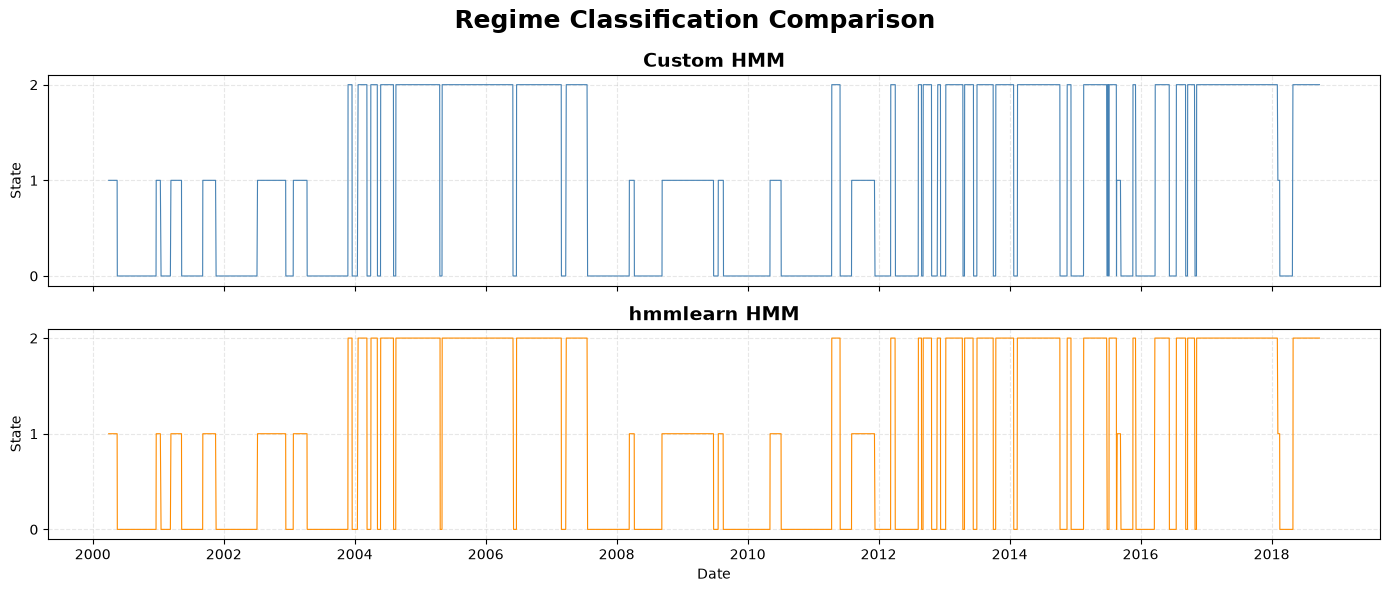

In [17]:
# Classification agreement
agreement = np.mean(custom_states == hmmlearn_states) * 100

print(f"State classification agreement: {agreement:.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Custom HMM
axes[0].plot(final_train_df.index, custom_states, linewidth=0.8, color="steelblue")
axes[0].set_title("Custom HMM", fontsize=14, fontweight="bold")

axes[0].set_ylabel("State")
axes[0].set_yticks([0, 1, 2])
axes[0].grid(True, linestyle="--", alpha=0.3)

# hmmlearn HMM
axes[1].plot(final_train_df.index, hmmlearn_states, linewidth=0.8, color="darkorange")
axes[1].set_title("hmmlearn HMM", fontsize=14, fontweight="bold")

axes[1].set_xlabel("Date")
axes[1].set_ylabel("State")
axes[1].set_yticks([0, 1, 2])
axes[1].grid(True, linestyle="--", alpha=0.3)

fig.suptitle("Regime Classification Comparison", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

#### Discussion 

The two implementations produce almost identical regime classifications, with a state agreement of 99.59%. The regime paths also show very similar transitions over time. This indicates that the custom HMM and hmmlearn classify market conditions in a highly consistent way.

### 7.4 Benchmark Conclusion

The benchmark shows that the custom HMM produces results highly consistent with hmmlearn. Both implementations converge to approximately the same log-likelihood, identify nearly identical regime characteristics, and achieve a state classification agreement of 99.59%. These results provide strong evidence that the custom HMM implementation is working correctly.

## 8. Final Model

The final HMM specification consists of three hidden states using 20-day momentum, GARCH conditional volatility, and VIX. The figure below shows the resulting regime classification together with the S&P 500 price series.

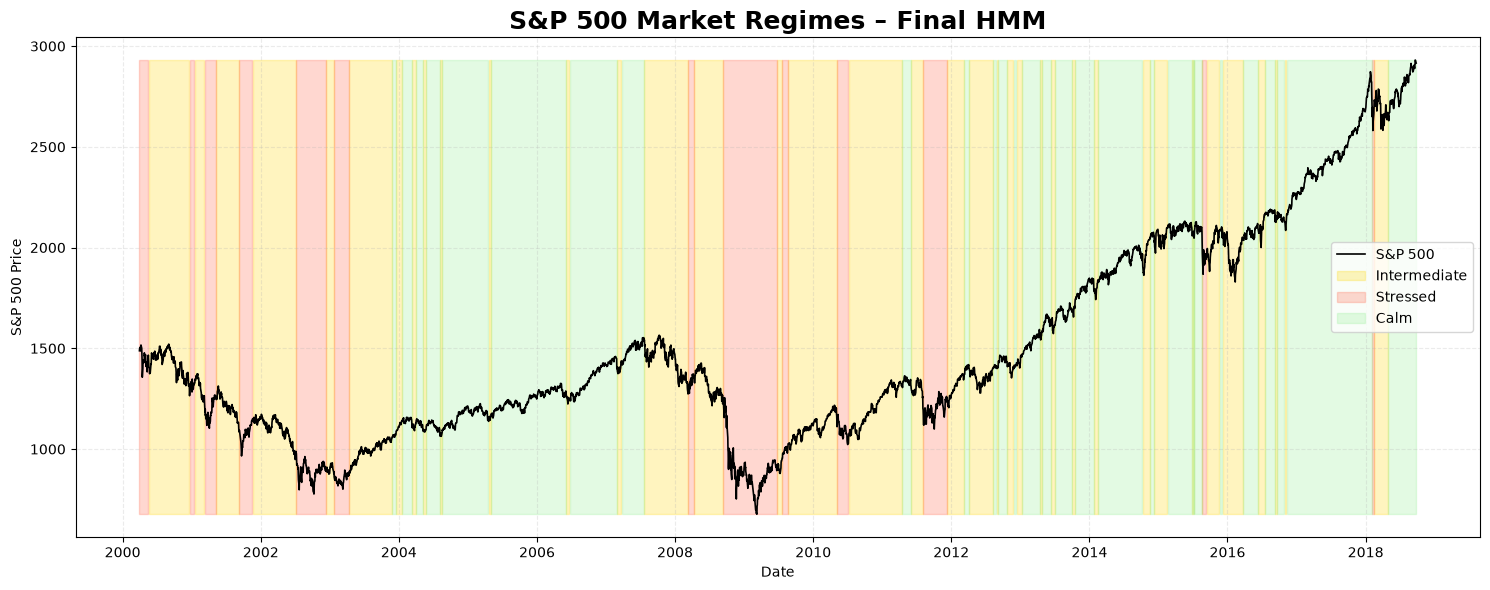

In [18]:
final_states = custom_states
final_prices = market_data.loc[final_train_df.index,"Close"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    final_prices.index,
    final_prices,
    color="black",
    linewidth=1.2,
    label="S&P 500"
)

state_colors = {
    0: "gold",
    1: "tomato",
    2: "lightgreen"
}

state_labels = {
    0: "Intermediate",
    1: "Stressed",
    2: "Calm"
}

for state in range(3):
    mask = final_states == state

    ax.fill_between(
        final_prices.index,
        final_prices.min(),
        final_prices.max(),
        where=mask,
        color=state_colors[state],
        alpha=0.25,
        label=state_labels[state]
    )

ax.set_title("S&P 500 Market Regimes – Final HMM", fontsize=18, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("S&P 500 Price")

ax.legend()
ax.grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Conclusion

The analysis shows that a three-state Hidden Markov Model can identify economically interpretable market regimes characterized by different levels of momentum and volatility. The robustness analysis supports the use of a relatively simple model, while VIX provides useful forward-looking risk information alongside momentum and GARCH conditional volatility.

The custom HMM implementation is also strongly validated against hmmlearn, producing nearly identical regime characteristics, log-likelihood, and state classifications. The resulting regime model will therefore be used in the next stage to investigate regime-dependent volatility dynamics and risk estimation.